## <div align="center">**SSC5974 - Métodos Computacionais Aplicados ao Mercado Financeiro**</div>
## <div align="center">**Trabalho 1**</div>
## <div align="center">**Matheus Queiroz Mota - 16767388**</div>

Para a realização deste trabalho, serão utilizados tanto os datasets fornecidos em aula quanto fragmentos dos códigos. Todavia, modificações serão feitas nas estruturas visando explorar abordagens diferentes daquelas passadas em sala.

### **Fatores de Análise Selecionados**
O estudo utilizou 10 fatores fundamentalistas e estatísticos de forma selecionada para cada modelo:
* **Momentum (`Mom6` / `Mom12` / `MTUM12`):** Capturam tendências de preço em curto e longo prazo, com o `MTUM12` filtrando choques de mercado.
* **Valuation (`PVP` / `EV_EBIT`):** Indicam ativos descontados em relação ao patrimônio líquido (`PVP`) ou potencialmente subavaliados pelo lucro operacional (`EV_EBIT`).
* **Rentabilidade (`ROIC` / `ROE`):** Medem a eficiência na geração de lucro com o capital alocado (`ROIC`) e a rentabilidade do capital do acionista (`ROE`).
* **Saúde Financeira (`EBIT_DIVLIQ`):** Avalia a capacidade de pagamento de dívidas através do lucro operacional.
* **Risco (`Volat6` / `Volat12`):** Mapeiam a volatilidade histórica, atuando como freio estatístico para suavizar quedas.

### **Metodologias de Ranqueamento de Fatores**
Para consolidar os múltiplos indicadores, o código implementou três metodologias, embora apenas duas tenham sido validadas no *Grid Search*:
* **Soma:** Consolida as notas ou posições do ativo em cada fator; os de maior pontuação são selecionados.
* **Percentil:** Padroniza os fatores em uma escala de 0% a 100%, permitindo a comparação direta de indicadores de naturezas distintas.
* **Z-Score:** Mede o distanciamento do ativo em relação à média da bolsa em desvios padrões (mantido no código, mas não utilizado nos modelos finais devido aos testes iniciais).

### **Abordagem Utilizada na Formação das Carteiras**
A estratégia adotou ponderação por **Pesos Iguais (Equal Weight - EW)**, tratando todos os fatores selecionados com a mesma relevância. Para garantir a consistência dos backtests, o *Grid Search* operou sob as seguintes restrições fixas:
* **Número de Ativos:** Exatamente 20 ações por carteira em cada período.
* **Combinações:** Estratégias restritas a uniões de apenas 3 ou 4 fatores simultâneos.
* **Ranqueamento:** Restrito aos métodos de Soma e Percentil.
* **Benchmark Alvo:** O Ibovespa (IBOV) foi o índice fixado como referência principal.

In [95]:
# Bibliotecas utilizadas neste trabalho
#import riskfolio as rp
import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [96]:
# O código deste bloco foi reutilzado dos exemplos vistos em sala e com as mesmas datas
start='1/2002'
end='12/2023'

dados = pd.read_csv('v5-DB-Acoes.csv', index_col=0)
indices_acc = pd.read_csv('v5-DB-Indices.csv')
indices_acc.set_index('Data', inplace=True)
indices = indices_acc.pct_change(fill_method=None)
def calc_dif_dates(start, end):
  data_dif = relativedelta(datetime.strptime(end, '%m/%Y'), datetime.strptime(start, '%m/%Y'))
  return data_dif.years + data_dif.months/12


## **Funções:**
Neste trabalho, foram desenvolvidas três funções:

- **criar_portifolio_multiplos_fatores():** Baseada em grande parte nos códigos desenvolvidos em sala, essa função busca expandir a análise para múltiplos fatores, além de possibilitar explorar outras formas de ranqueamento (Soma, Z-Score e Percentil). Apesar do método Z-Score não ter sido exibido neste código, por ter tido um desempenho pior em testes anteriores, optei por deixá-lo como opção de escolha neste código.

- **grid_search_fatores():** Esta função testa as combinações de fatores para análise, rodando backtests automatizados para descobrir qual é o melhor conjunto de indicadores para um objetivo específico (como Maior Retorno,Maior Retorno/Volaatilidade, Menor Volatilidade ou Maior Alpha). A premissa dela é testar todas as possibilidades de cruzamento (pares, trincas, etc.), o que a torna computacionalmente muito cara. Por isso, para usar ela, deve-se ter em mente o que se deseja otimizar e quais seriam os fatores mais indicados para chegar nessa otimização, evitando testar a base inteira às cegas e sobrecarregar o processamento.

- **plotar_graficos():** Esta função é responsável por gerar os gráficos solicitados pelo trabalho. As especificações da lista e uso estão descritas no corpo da função.

In [97]:
import pandas as pd
import statsmodels.api as sm

def criar_portifolio_multiplos_fatores(filtro_fim, dados, referencias, fator_ranking_style, fatores, verbose=True):
    """
    Realiza o backtest de uma carteira multifatorial com pesos iguais (Equal Weight).
    Seleciona as N melhores ações mês a mês com base nos fatores escolhidos
    e calcula métricas de performance contra múltiplos benchmarks.

    Parâmetros:
    - filtro_fim (int): Quantidade de ações compradas por mês (ex: 20).
    - dados (df): Base histórica contendo datas, retornos e indicadores.
    - referencias (Series ou DataFrame): Histórico de retornos dos benchmarks (ex: indices[['IBOV', 'IBXX', 'SELIC']]).
    - fator_ranking_style (str): Método de combinação do ranking ("Soma", "Z-Score" ou "Percentil").
    - fatores (list): Lista com os nomes dos fatores testados (ex: ['Mom6', 'ROIC']).
    - verbose (bool): Se True, imprime a tabela comparativa no final.

    Retorna:
    - Port1: DataFrame com o histórico de retornos mensais da carteira.
    """
    cost_trans = 0.0006
    ascending_dic = {'ROIC': False, 'ROE': False, 'EV_EBIT': True,'EBIT_DIVLIQ': False,'PVP': True,'Mom12': False,
                     'Mom6': False,'Volat12': True,'Volat6': True,'MTUM6': False,'MTUM12': False }
    list_date = []
    list_ret = []
    for dt in pd.date_range(start=start, end=end, freq='ME').strftime('%b-%Y'):
        carteira = dados.loc[(dados['Data']==dt) & (dados['IBX'] > 0) & (dados['Retorno'].isnull() == False)].copy()
        
        if fator_ranking_style == "Soma":
            rank_cols = []
            for f in fatores:
                rank_name = f'rank_{f}'
                carteira[rank_name] = carteira[f].rank(ascending=ascending_dic[f])
                rank_cols.append(rank_name)
            carteira['Rank_Soma'] = carteira[rank_cols].sum(axis=1, skipna=False) # Aqui coloquei o slipna como false pois no codigo em sala estava assim
            carteira['rank_final'] = carteira['Rank_Soma'].rank(ascending=True)
        
        # Observação: Nos testes deste trabalho realizados com o Z-score, nenhum resultado conseguiu um desempenho melhor que o método
        # da soma ou percentil. E visando não rodar muitos casos na função do grid search, o método do Z-score não foi utilizado na
        # versão final do trabalho. Porém, deixarei sua função aqui para o caso de novos testes por parte do avaliador caso queira.
        
        elif fator_ranking_style == "Z-Score":
            z_cols = []
            for f in fatores:
                media = carteira[f].mean()
                desvio = carteira[f].std()
                z = 0.0 if desvio == 0 else (carteira[f] - media)/desvio
                if ascending_dic[f]:
                    z = z * (-1)
                z_name = f'z_{f}'
                carteira[z_name] = z
                z_cols.append(z_name)
            carteira['Rank_Z_Score'] = carteira[z_cols].sum(axis=1, skipna=False)
            carteira['rank_final'] = carteira['Rank_Z_Score'].rank(ascending=False)
            
        elif fator_ranking_style == "Percentil":
            perc_cols = []
            for f in fatores:
                if ascending_dic[f] == False:   
                    perc = carteira[f].rank(pct=True, ascending=True)
                else:                           
                    perc = carteira[f].rank(pct=True, ascending=False)
                perc_name = f'perc_{f}'
                carteira[perc_name] = perc
                perc_cols.append(perc_name)
            carteira['Rank_Percentil'] = carteira[perc_cols].mean(axis=1, skipna=False)
            carteira['rank_final'] = carteira['Rank_Percentil'].rank(ascending=False)
        ret = carteira.loc[(carteira['rank_final'] <= filtro_fim)]['Retorno'].mean() - cost_trans

        list_date.append(dt)
        list_ret.append(ret)
    
    Port1 = pd.DataFrame({'Data': list_date, 'Ret': list_ret})
    Port1.set_index('Data', inplace=True)
    Port1['Ret_acc'] = (1 + Port1['Ret']).cumprod() - 1 
    Port1['acc_max'] = Port1['Ret_acc'].cummax()
    Port1['drawdown'] = ((1 + Port1['Ret_acc']) / (1 + Port1['acc_max'])) - 1

    anos_passados = calc_dif_dates(start, end)
    
    ret_acc_port = Port1['Ret_acc'].iloc[-1]
    ret_aa_port = (pow(1 + ret_acc_port, 1 / anos_passados) - 1)
    vol_aa_port = Port1['Ret'].std() * (12 ** 0.5)
    ret_vol_port = ret_aa_port / vol_aa_port if vol_aa_port != 0 else 0
    drawdown_port = Port1['drawdown'].min()

    tabela = []
    
    tabela.append({
        'Ativo': f"Carteira ({fator_ranking_style})",
        'Ret. Acumulado (%)': round(ret_acc_port * 100, 2),
        'Ret. Anualizado (%)': round(ret_aa_port * 100, 2),
        'Volatilidade (%)': round(vol_aa_port * 100, 2),
        'Retorno/Volatilidade': round(ret_vol_port, 2),
        'Drawdown Máximo (%)': round(drawdown_port * 100, 2),
        'Alpha vs Ref (%)': '-',
        'P-val Alpha': '-',
        'Beta vs Ref': '-',
        'P-val Beta': '-'
    })
    # Nesta parte é só uma etapa de segurança para o leitor dos benchmarks não dar erro (por ser pd.series ou pd.df dependendo da entrada)
    if isinstance(referencias, pd.Series):
        referencias = referencias.to_frame(name='Benchmark')

    # Eu criei esta função para poder retornar em uma mesma tabela os valores de alpha e beta com mais de um índice de comparação

    for col in referencias.columns:

        # Basicamente estes são os mesmos calculos feitos no código em sala...
        ref_ret = referencias[col].loc[Port1.index]
        ref_acc = (1 + ref_ret).cumprod() - 1
        
        Port1[col] = ref_ret
        Port1[f'{col}_acc'] = ref_acc

        ret_acc_ref = ref_acc.iloc[-1]
        ret_aa_ref = (pow(1 + ret_acc_ref, 1 / anos_passados) - 1)
        vol_aa_ref = ref_ret.std() * (12 ** 0.5)
        ret_vol_ref = ret_aa_ref / vol_aa_ref if vol_aa_ref != 0 else 0
        acc_max_ref = ref_acc.cummax()
        drawdown_ref = (((1 + ref_acc) / (1 + acc_max_ref)) - 1).min()
        Port1['Ref'] = ref_ret 
        model = sm.OLS(Port1['Ret'].to_list(), sm.add_constant(Port1['Ref'].to_list()), missing='drop').fit()
        alpha_anualizado = model.params[0] * 12
        beta = model.params[1]
        p_alpha = model.pvalues[0]
        p_beta = model.pvalues[1]
        tabela.append({
            'Ativo': col,
            'Ret. Acumulado (%)': round(ret_acc_ref*100, 2),
            'Ret. Anualizado (%)': round(ret_aa_ref*100, 2),
            'Volatilidade (%)': round(vol_aa_ref*100, 2),
            'Retorno/Volatilidade': round(ret_vol_ref, 2),
            'Drawdown Máximo (%)': round(drawdown_ref*100, 2),
            'Alpha vs Ref (%)': round(alpha_anualizado*100, 2),
            'P-val Alpha': round(p_alpha, 4),
            'Beta vs Ref': round(beta, 2),
            'P-val Beta': round(p_beta, 4)
        })
    df_comparativo = pd.DataFrame(tabela)
    # Observação: Verbose é uma pratica comum em python, quando há prints ou exibições dentro de funções. Se ela for True, a exibição aparece, 
    # caso contrário, não.
    # Essa etapa será importante na hora de passar a criação do portifólio para o Grid Search, para evitar a poluição visual de diversos prints na tela.
    if verbose==True:
        print(f"\n{'='*60}")
        print(f"ANÁLISE DE PERFORMANCE: Portfolio [{', '.join(fatores)}]")
        print(f"{'='*60}")
        from IPython.display import display
        #print(df_comparativo.to_markdown(index=False))
        display(df_comparativo)
    # Estes metadados serão importantes na hora de criar os nomes personalizados para os gráficos
    Port1.attrs['metodo_utilizado'] = fator_ranking_style
    Port1.attrs['fatores_usados'] = fatores
    Port1.attrs['nome_carteira'] = f"Port{len(fatores)}"

    return Port1.copy()

In [98]:
import itertools
import pandas as pd
import statsmodels.api as sm # Importação necessária para o Alpha/Beta

def grid_search_fatores(fatores_disponiveis, list_num_fatores, objetivo, filtro_fim, dados, referencia,list_ranking_styles=['Soma']):
    """
    Realiza a mineração de fatores testando todas as combinações possíveis via Grid Search.
    
    Parâmetros:
    - fatores_disponiveis (list): Lista com os nomes dos fatores que serão combinados e testados (ex: ['Mom6', 'ROIC', 'Volat12']).
    - list_num_fatores (list): Quantidade de fatores agrupados em cada teste (ex: [2, 3] para testar em pares e trincas).
    - objetivo (str): Métrica de otimização que o algoritmo deve buscar: 'Retorno', 'Retorno/Volatilidade', 'Volatilidade' ou 'Alpha'.
    - filtro_fim (int): Quantidade de ações que serão selecionadas para compor a carteira a cada mês (ex: 20).
    - dados (pd.DataFrame): Base de dados histórica contendo as datas, os retornos e os indicadores das empresas.
    - referencia (pd.Series): Histórico de retornos mensais do benchmark (ex: Ibovespa), necessário para o cálculo do Alpha e Beta.
    - list_ranking_styles (list): Métodos de ranqueamento a serem testados (ex: ['Soma', 'Z-Score', 'Percentil']). O padrão é ['Soma'].
    
    Retorna:
    - melhor_combinacao (tuple): A lista exata de fatores que venceu a otimização.
    - df_resultados (pd.DataFrame): Uma tabela completa com o ranking de todas as combinações testadas e suas respectivas métricas.

    Observação: Este método é uma espécie de força bruta, logo, antes de realizar sua execução, é importante ter em mente a lista fatores que possam formar
    um bom resultado no objetivo a ser otimizado. Sendo assim, acarreta em menos combinações desnecessárias na execução.
    """
    resultados_lista = []
    
    # Achei interessante essa parte de exibição para que o usuário possa ter ideia de quantos backtestes serão realizados com os itens passados nas entradas.
    total_backtests = 0
    for n_f in list_num_fatores:
        total_backtests += len(list(itertools.combinations(fatores_disponiveis, n_f)))
    total_backtests = total_backtests * len(list_ranking_styles)
    
    print("Grid Search:")
    print(f"Total de backtests programados: {total_backtests}")

    for ranking_style in list_ranking_styles:
        for num_fatores in list_num_fatores:
            combinacoes = list(itertools.combinations(fatores_disponiveis, num_fatores))
            print(f"Testando [{ranking_style}] com {num_fatores} fatores ({len(combinacoes)} combinações)...")
            
            for comb in combinacoes:
                lista_fatores = list(comb)
                
                port_temp = criar_portifolio_multiplos_fatores(
                    filtro_fim=filtro_fim,
                    dados=dados,
                    referencias=referencia,
                    fator_ranking_style=ranking_style,
                    fatores=lista_fatores, 
                    verbose=False # Esta parte deve ser mantida como false para que não ocorra uma poluição visual com diversos prints na tela
                )
                
                meses = port_temp.shape[0]
                if meses == 0:
                    continue
                retorno_acc = port_temp['Ret_acc'].iloc[-1]
                retorno_anualizado = (pow(retorno_acc + 1, 1/calc_dif_dates(start, end)) - 1)
                vol_anualizada = port_temp['Ret'].std()*(12**(1/2))
                acc_max = port_temp['Ret_acc'].cummax()
                drawdown_maximo = (((1 + port_temp['Ret_acc']) / (1 + acc_max)) - 1).min()
                
                # Divisão simples (evitando erro de divisão por zero)
                ret_vol_ratio = 0 if vol_anualizada == 0 else retorno_anualizado / vol_anualizada
                
                # Cálculo do Alpha e Beta do Modelo
               
                df_reg = port_temp[['Ret', 'Ref']]
                model = sm.OLS(df_reg['Ret'].to_list(), sm.add_constant(df_reg['Ref'].to_list()), missing='drop').fit()

                alpha_anualizado = model.params[0] * 12
                beta_carteira = model.params[1]
                
                # Regras de Objetivo
                if objetivo == 'Retorno':
                    score = retorno_acc
                elif objetivo == 'Retorno/Volatilidade':
                    score = ret_vol_ratio 
                elif objetivo == 'Volatilidade':
                    score = vol_anualizada
                elif objetivo == 'Alpha':
                    score = alpha_anualizado
                    
                resultados_lista.append({
                    'Método': ranking_style,
                    'Qtd Fatores': num_fatores,
                    'Combinação': lista_fatores,
                    'Retorno Anualizado (%)': round(retorno_anualizado * 100, 2),
                    'Retorno Acumulado (%)': round(retorno_acc*100,2),
                    'Volatilidade (%)': round(vol_anualizada * 100, 2),
                    'Alpha Anualizado (%)': round(alpha_anualizado * 100, 2),
                    'Beta': round(beta_carteira, 2),
                    'Drawdown (%)': round(drawdown_maximo * 100, 2),
                    'Retorno/Volatilidade': round(ret_vol_ratio, 2),
                    f'Score {objetivo}': score
                })

    df_resultados = pd.DataFrame(resultados_lista)
    
    ordem_crescente = True if objetivo == 'Volatilidade' else False
    df_resultados = df_resultados.sort_values(by=f'Score {objetivo}', ascending=ordem_crescente).reset_index(drop=True)
    
    melhor_combinacao = df_resultados.iloc[0]['Combinação']
    melhor_metodo = df_resultados.iloc[0]['Método']
    score_maximo = df_resultados.iloc[0][f'Score {objetivo}']
    
    print("FIM DO GRID Search")
    print(f"Objetivo: {objetivo}")
    print(f"Melhor Método de Ranking: {melhor_metodo}")
    print(f"Melhor Combinação Encontrada: {melhor_combinacao}")
    
    if objetivo == 'Retorno':
        print(f"Retorno Máximo Atingido: {round(score_maximo * 100, 2)}%\n")
    elif objetivo == 'Volatilidade':
        print(f"Volatilidade Mínima Atingida: {round(score_maximo * 100, 2)}%\n")
    elif objetivo == 'Alpha':
        print(f"Maior Alpha (Retorno Excedente) Atingido: {round(score_maximo * 100, 2)}%\n")
    else:
        print(f"Retorno/Volatilidade Atingido: {round(score_maximo, 4)}\n")
    
    return melhor_combinacao, df_resultados

In [99]:
def plotar_dashboard_comparativo(lista_portfolios):
    """
    Este código é uma função que plota os 4 gráficos do trabalho. Nela podemos adicionar até três portifólios para comparar,
    que devem ser fornecidos em formato de lista.
    ex: lista_portifolios = [Port1, Por2, Port3]
    Note que na própria função do portifolio temos os índices de referência, esse código remove as duplicatas e engloba todos os 
    índices passados nos portifólios.
    """
    for port in lista_portfolios:
        port.index = pd.to_datetime(port.index)
    
    plt.style.use('fivethirtyeight')
    fig, axes = plt.subplots(2, 2, figsize=(16, 10)) 
    axes = axes.flatten()
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    cores_carteiras = ["#004F88", "#FC0022", "#FF7F29"]
    cores_benchmark = {
        'IBOV': "#CEA17A", 'IBXX': "#6DF56D", 'SELIC': "#06441B", 'IVVB11': '#9467BD', 
        'IPCA': '#7F7F7F', 'USD': '#17BECF', 'GOLD11': '#BCBD22', 'GOLD': '#DBDB8D', 
        'SP500US': '#8C564B', 'SP500BR': '#C49C94', 'IBRA': '#98DF8A', 'IGPM': '#C7C7C7', 
        'IMAB5': '#F7B6D2', 'IMA-B': '#E377C2', 'IRF-M': '#C5B0D5', 'IMA-S': '#FF9896'
    }

    indices_unicos = []
    for port in lista_portfolios:
        for col in port.columns:
            if col.endswith('_acc') and col != 'Ret_acc': 
                nome_indice = col.replace('_acc', '') 
                if nome_indice not in indices_unicos:
                    indices_unicos.append(nome_indice)

    for bench in indices_unicos:
        cor_bench = cores_benchmark.get(bench, '#000000')
        col_acc = f'{bench}_acc'
        
        df_fonte = None
        for port in lista_portfolios:
            if col_acc in port.columns:
                df_fonte = port
                break
                
        if df_fonte is not None:
            axes[0].plot(df_fonte.index, df_fonte[col_acc] * 100, label=bench, color=cor_bench, linewidth=1.5, alpha=0.8)
            movel_bench = (1 + df_fonte[bench]).rolling(60).apply(np.prod, raw=True) - 1
            axes[1].plot(df_fonte.index, movel_bench * 100, label=f'{bench} (60m)', color=cor_bench, linewidth=1.5, alpha=0.8)
            vol_bench = df_fonte[bench].rolling(12).std()*(12 ** 0.5)
            axes[2].plot(df_fonte.index, vol_bench * 100, label=f'Vol {bench}', color=cor_bench, linewidth=1.5, alpha=0.8)
            
            max_bench = df_fonte[col_acc].cummax()
            dd_bench = ((1 + df_fonte[col_acc]) / (1 + max_bench)) - 1
            axes[3].plot(df_fonte.index, dd_bench * 100, label=f'DD {bench}', color=cor_bench, linewidth=1.5, linestyle=':')

    for i, modelo in enumerate(lista_portfolios[:3]): 
        cor_port = cores_carteiras[i]
        
        metodo = modelo.attrs.get('metodo_utilizado', f'Carteira {i+1}')
        fatores = modelo.attrs.get('fatores_usados', [])
        nome_label = f"{metodo}: " + " ".join(fatores) if fatores else metodo
        
        axes[0].plot(modelo.index, modelo['Ret_acc'] * 100, label=nome_label, color=cor_port, linewidth=1.8)
        
        movel_port = (1 + modelo['Ret']).rolling(60).apply(np.prod, raw=True) - 1
        axes[1].plot(modelo.index, movel_port * 100, label=f'{nome_label} (60m)', color=cor_port, linewidth=2)
        
        vol_port = modelo['Ret'].rolling(12).std() * (12 ** 0.5)
        axes[2].plot(modelo.index, vol_port * 100, label=f'Vol {nome_label}', color=cor_port, linewidth=2)
        
        max_port = modelo['Ret_acc'].cummax()
        dd_port = ((1 + modelo['Ret_acc']) / (1 + max_port)) - 1
        axes[3].fill_between(modelo.index, dd_port * 100, 0, color=cor_port, alpha=0.3)
        axes[3].plot(modelo.index, dd_port * 100, color=cor_port, linewidth=1.5)

    titulos = [
        '1. Retorno Acumulado Histórico', 
        '2. Retorno Móvel (60 Meses)', 
        '3. Volatilidade Anualizada Móvel (12 Meses)', 
        '4. Drawdown Histórico'
    ]
    ylabels = ['Retorno (%)', 'Retorno (%)', 'Volatilidade (%)', 'Queda (%)']

    for ax, titulo, ylabel in zip(axes, titulos, ylabels):
        ax.set_title(titulo, fontsize=14, fontweight='bold', loc='left')
        ax.set_ylabel(ylabel)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        
        # Nessa parte eu adicionei esses if's para que a caixa da legenda não cubrisse o gráfico
        ax.margins(y=0.15) 
        if titulo == '4. Drawdown Histórico':
            loc_legenda = 'lower left'
            ax.set_ylim(top=0)
        elif titulo == '3. Volatilidade Anualizada Móvel (12 Meses)':
            loc_legenda = 'upper center'
            ax.set_ylim(bottom=0)

        elif titulo == '2. Retorno Móvel (60 Meses)':
            loc_legenda = 'upper right'
            ax.set_ylim(bottom=0)
        else:
            loc_legenda = 'upper left'
            if titulo == '1. Retorno Acumulado Histórico':
                ax.set_ylim(bottom=0)
                
        ax.legend(loc=loc_legenda, frameon=True, fontsize=10)
        
        if 'Retorno Móvel' in titulo:
            ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            
        ax.tick_params(axis='y', pad=10)
        ax.tick_params(labelbottom=True) 
        ax.xaxis.set_major_locator(mdates.YearLocator(3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) 
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

    plt.show()

## **Modelo 1 - Maior Retorno Acumulado:**

Neste modelo, o objetivo é construir uma carteira capaz de maximizar o retorno absoluto no longo prazo. Para isso, foi estruturado um teste comparativo utilizando a função **grid_search_fatores()** em duas etapas distintas.

Na primeira busca, adotou-se uma abordagem teórica realizando testes com fatores associados estritamente ao ganho direcional, sem penalizar o risco corrido:

- **Momentos, ROE, PVP** e **EV_EBIT**: A premissa clássica de comprar os ativos que estão com a maior força de alta e que entregam o maior lucro contábil aparente, ignorando totalmente a volatilidade e os solavancos do mercado ou períodos de crise.

Na segunda busca, o escopo do algoritmo será ampliado com a inclusão de métricas focadas em controle de risco:

- Baixa Volatilidade (**Volat12**), Momentum Ajustado (**MTUM12**) e Qualidade (**ROIC**): O intuito aqui é verificar como a rentabilidade de longo prazo se comporta ao inserirmos um "freio estatístico". A ideia é analisar se estes fatores causam a redução de grandes quedas na carteira (comprando ações menos erráticas e mais previsíveis), de modo a proteger o capital nas crises e permitir que o efeito dos juros compostos gere um retorno final superior ao do modelo puramente agressivo.



In [100]:
# Grid Search dos fatores de ganho apenas
melhor_comb_m1, resultados_m1 = grid_search_fatores(
    fatores_disponiveis=['Mom6','EV_EBIT','ROE','PVP','Mom12'],
    list_num_fatores=[3,4],
    objetivo='Retorno',     
    filtro_fim=20,      
    dados=dados,
    referencia=indices['IBOV'],
    list_ranking_styles=['Soma', 'Percentil']
)


Grid Search:
Total de backtests programados: 30
Testando [Soma] com 3 fatores (10 combinações)...
Testando [Soma] com 4 fatores (5 combinações)...
Testando [Percentil] com 3 fatores (10 combinações)...
Testando [Percentil] com 4 fatores (5 combinações)...
FIM DO GRID Search
Objetivo: Retorno
Melhor Método de Ranking: Soma
Melhor Combinação Encontrada: ['Mom6', 'ROE', 'PVP', 'Mom12']
Retorno Máximo Atingido: 11297.91%



In [101]:
resultados_m1.head(5)

,Método,Qtd Fatores,Combinação,Retorno Anualizado (%),Retorno Acumulado (%),Volatilidade (%),Alpha Anualizado (%),Beta,Drawdown (%),Retorno/Volatilidade,Score Retorno
0,Soma,4,"[Mom6, ROE, PVP, Mom12]",24.12,11297.91,22.31,14.04,0.79,-41.88,1.08,112.979071
1,Percentil,4,"[Mom6, ROE, PVP, Mom12]",23.86,10775.02,22.20,13.85,0.78,-42.24,1.07,107.750219
2,Soma,3,"[ROE, PVP, Mom12]",22.96,9178.68,22.63,12.74,0.82,-43.58,1.01,91.786776
3,Soma,3,"[Mom6, ROE, PVP]",22.71,8763.10,22.75,12.49,0.82,-39.47,1.00,87.631008
4,Percentil,3,"[ROE, PVP, Mom12]",21.95,7637.45,22.37,11.94,0.81,-44.89,0.98,76.374485


In [102]:
# Grid Search considerando os fatores de qualidade e controle de risco (Optei por adicionar apenas o Volat6, senão o número de backtests
# iria saltar de 140 para 252)
melhor_comb_m2, resultados_m2 = grid_search_fatores(
    fatores_disponiveis=['ROIC','ROE','Mom6','PVP','Volat12','MTUM12','Mom12'],
    list_num_fatores=[3,4],
    objetivo='Retorno',     
    filtro_fim=20,      
    dados=dados,
    referencia=indices['IBOV'],
    list_ranking_styles=['Soma', 'Percentil']
)

Grid Search:
Total de backtests programados: 140
Testando [Soma] com 3 fatores (35 combinações)...
Testando [Soma] com 4 fatores (35 combinações)...
Testando [Percentil] com 3 fatores (35 combinações)...
Testando [Percentil] com 4 fatores (35 combinações)...
FIM DO GRID Search
Objetivo: Retorno
Melhor Método de Ranking: Soma
Melhor Combinação Encontrada: ['ROIC', 'PVP', 'MTUM12']
Retorno Máximo Atingido: 13312.69%



In [103]:
# Top 5 Retornos, com fatores de risco e qualidade inclusos
# Note que o segundo colocado [Mom6,PVP,Volat12] teve um acumulo ligeiramente menor, mas em compensação um
# Drawdown e volatilidade menores, além de um Retorno/Volatilidade mais superior
resultados_m2.head(5)


,Método,Qtd Fatores,Combinação,Retorno Anualizado (%),Retorno Acumulado (%),Volatilidade (%),Alpha Anualizado (%),Beta,Drawdown (%),Retorno/Volatilidade,Score Retorno
0,Soma,3,"[ROIC, PVP, MTUM12]",25.05,13312.69,20.97,15.00,0.75,-44.25,1.19,133.126932
1,Soma,3,"[Mom6, PVP, Volat12]",25.01,13224.92,20.47,15.36,0.71,-32.94,1.22,132.249204
2,Percentil,4,"[Mom6, PVP, Volat12, Mom12]",24.93,13037.47,20.61,15.46,0.70,-35.54,1.21,130.374652
3,Soma,4,"[Mom6, PVP, Volat12, Mom12]",24.74,12605.07,20.67,15.33,0.70,-36.47,1.20,126.050744
4,Percentil,3,"[Mom6, PVP, Volat12]",24.73,12577.86,20.59,15.04,0.72,-33.22,1.20,125.778552


In [104]:
"""
- Modelo_ret1_s_v: Modelo que contem apenas os fatores de valor (linha vermelha nos gráficos);

- Modelo_ret1_c_v: Modelo que contem fatores de valor, qualidade e controle de risco e que obteve 
  o maior valor acumulado ['PVP', 'MTUM12', 'ROIC'] (linha azul nos gráficos);

- Modelo_ret1_c_v2: Modelo que, apesar de ter um retornono acumulado ligeiramente menor que o anterior,
  teve um bom desempenho na volatilidade e drawdown ['PVP', 'Mom6', 'Volat12'] (linha laranja nos gráficos)
"""
Modelo_ret1_s_v = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'IBXX', 'SELIC']],'Soma',['Mom6', 'ROE', 'PVP', 'Mom12'],verbose=True)
Modelo_ret1_c_v= criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'IBXX', 'SELIC']],'Soma',['PVP', 'MTUM12', 'ROIC'],verbose=True)
Modelo_ret1_c_v2 = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'IBXX', 'SELIC']],'Soma',['PVP', 'Mom6', 'Volat12'],verbose=True)	




ANÁLISE DE PERFORMANCE: Portfolio [Mom6, ROE, PVP, Mom12]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),11297.91,24.12,22.31,1.08,-41.88,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,14.04,0.0,0.79,0.0
2,IBXX,1581.81,13.74,22.46,0.61,-49.74,11.14,0.0,0.85,0.0
3,SELIC,1017.88,11.64,1.32,8.82,0.00,8.9,0.4767,1.39,0.1824



ANÁLISE DE PERFORMANCE: Portfolio [PVP, MTUM12, ROIC]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),13312.69,25.05,20.97,1.19,-44.25,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,15.0,0.0,0.75,0.0
2,IBXX,1581.81,13.74,22.46,0.61,-49.74,12.27,0.0,0.81,0.0
3,SELIC,1017.88,11.64,1.32,8.82,0.00,6.84,0.5599,1.62,0.099



ANÁLISE DE PERFORMANCE: Portfolio [PVP, Mom6, Volat12]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),13224.92,25.01,20.47,1.22,-32.94,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,15.36,0.0,0.71,0.0
2,IBXX,1581.81,13.74,22.46,0.61,-49.74,12.88,0.0,0.76,0.0
3,SELIC,1017.88,11.64,1.32,8.82,0.00,4.09,0.7207,1.85,0.0527


### **Resultados do Modelo 1**

Os resultados obtidos comprovam que mesclar fatores de valor e qualidade (PVP e ROIC) com métricas de controle de risco (MTUM12 e Volat12) é significativamente superior a adotar uma estratégia puramente baseada em fatores de valor e momentum. **A carteira composta apenas por fatores agressivos (em vermelho [Mom6, ROE, PVP, Mom12])** entregou o menor ganho acumulado (11.297,91%), pois a ausência de um “freio estatístico” a deixou mais exposta à volatilidade, penalizando a eficiência dos juros compostos ao longo do tempo.

Em contrapartida, as abordagens híbridas dominaram o teste. A **carteira Azul ([PVP, MTUM12, ROIC])** registrou o maior retorno absoluto do período, atingindo 13.312,69% de ganho acumulado.
A **carteira laranja ([PVP, Mom6, Volat12])**, por sua vez, destacou-se pela excelente gestão de risco: conseguiu um Drawdown Máximo bem mais controlado, na faixa de -32,94%, especialmente nas crises de 2008 e da pandemia de 2020 — um desempenho claramente superior às outras duas carteiras e aos índices de referência (IBOV e IBXX), que ultrapassaram os -49% no pior momento. Além disso, a inclusão do fator Volat12 resultou na carteira menos volátil (20,47%) e no melhor índice de Retorno/Volatilidade (1,22) entre os três modelos testados.

Deste modo, podemos concluir que a inclusão de filtros de Qualidade (ROIC) ou de Baixa Volatilidade (Volat12) não representou obstáculo ao crescimento. Pelo contrário: atuaram como verdadeiros estabilizadores, reduzindo a severidade das quedas nos momentos de crise e permitindo que o efeito dos juros compostos operasse com muito mais eficiência no longo prazo.

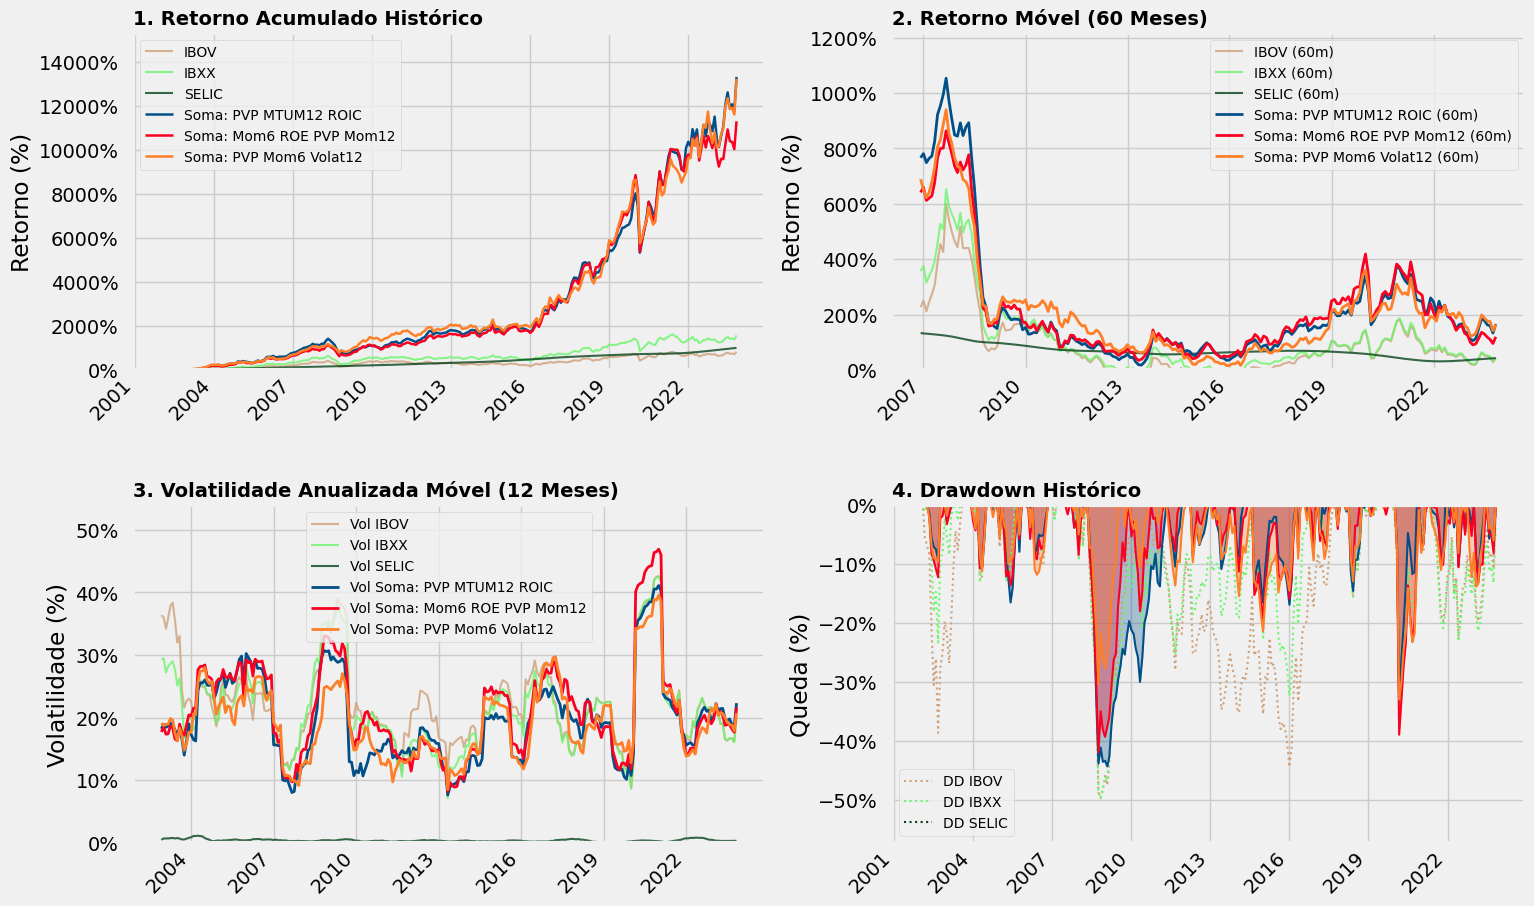

In [105]:
plotar_dashboard_comparativo([Modelo_ret1_c_v,Modelo_ret1_s_v,Modelo_ret1_c_v2]);

## **Modelo 2: Retorno/Volatilidade**

Neste modelo, o objetivo é identificar a combinação de fatores capaz de maximizar a relação **retorno/volatilidade**, buscando não apenas alto retorno, mas maior eficiência no risco assumido.

Com base nos resultados obtidos no Modelo 1, realizamos novo um grid search utilizando a função **grid_search_fatores()**, agora com o objetivo configurado para 'Retorno/Volatilidade', testando combinações entre os fatores mais relevantes identificados anteriormente (**ROIC, Mom6, PVP, Volat12, MTUM12** e **ROE**).

In [106]:
melhor_comb_m2_sh, resultados_m2_sh = grid_search_fatores(
    fatores_disponiveis=['ROIC','Mom6','PVP','Volat12','MTUM12','ROE'],
    list_num_fatores=[3,4],
    objetivo='Retorno/Volatilidade',     
    filtro_fim=20,      
    dados=dados,
    referencia=indices['IBOV'],
    list_ranking_styles=['Soma', 'Percentil']
);

Grid Search:
Total de backtests programados: 70
Testando [Soma] com 3 fatores (20 combinações)...
Testando [Soma] com 4 fatores (15 combinações)...
Testando [Percentil] com 3 fatores (20 combinações)...
Testando [Percentil] com 4 fatores (15 combinações)...
FIM DO GRID Search
Objetivo: Retorno/Volatilidade
Melhor Método de Ranking: Soma
Melhor Combinação Encontrada: ['ROIC', 'Mom6', 'Volat12']
Retorno/Volatilidade Atingido: 1.2426



In [107]:
# 5 Modelos com o melhor desempenho no Retorno/Volatilidade:
resultados_m2_sh.head(5)

,Método,Qtd Fatores,Combinação,Retorno Anualizado (%),Retorno Acumulado (%),Volatilidade (%),Alpha Anualizado (%),Beta,Drawdown (%),Retorno/Volatilidade,Score Retorno/Volatilidade
0,Soma,3,"[ROIC, Mom6, Volat12]",21.40,6915.84,17.22,13.29,0.59,-30.34,1.24,1.242631
1,Soma,4,"[ROIC, Mom6, PVP, Volat12]",22.55,8515.46,18.31,13.97,0.63,-31.96,1.23,1.231454
2,Percentil,3,"[ROIC, Mom6, Volat12]",21.43,6945.55,17.41,13.24,0.60,-30.50,1.23,1.230926
3,Soma,3,"[Mom6, PVP, Volat12]",25.01,13224.92,20.47,15.36,0.71,-32.94,1.22,1.221733
4,Percentil,3,"[ROIC, PVP, MTUM12]",24.71,12548.59,20.51,14.87,0.73,-42.23,1.21,1.205105


In [108]:
Modelo2_ret_vol1 = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'SELIC','IBXX']],'Soma',['ROIC', 'Mom6', 'Volat12'],verbose=True)
modelo2_ret_vol2 = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'SELIC','IBXX']],'Soma',['PVP', 'Mom6', 'Volat12'],verbose=True)


ANÁLISE DE PERFORMANCE: Portfolio [ROIC, Mom6, Volat12]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),6915.84,21.40,17.22,1.24,-30.34,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,13.29,0.0,0.59,0.0
2,SELIC,1017.88,11.64,1.32,8.82,0.00,5.56,0.5639,1.4,0.0825
3,IBXX,1581.81,13.74,22.46,0.61,-49.74,11.04,0.0,0.65,0.0



ANÁLISE DE PERFORMANCE: Portfolio [PVP, Mom6, Volat12]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),13224.92,25.01,20.47,1.22,-32.94,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,15.36,0.0,0.71,0.0
2,SELIC,1017.88,11.64,1.32,8.82,0.00,4.09,0.7207,1.85,0.0527
3,IBXX,1581.81,13.74,22.46,0.61,-49.74,12.88,0.0,0.76,0.0


### **Resultados do Modelo 2**
Os resultados do Modelo 2 reforçam a importância de equilibrar retorno e risco. Ao buscar a maximização da relação Retorno/Volatilidade, o grid search identificou combinações que entregam carteiras mais eficientes, especialmente quando incorporamos fatores de qualidade e controle de risco.

A carteira que apresentou o **melhor Retorno/Volatilidade** foi a composta por **[ROIC, Mom6, Volat12]** **(valor de 1,24)**, com volatilidade anualizada de apenas 17,22% e um Drawdown Máximo controlado em -30,34%. Essa combinação prioriza qualidade operacional e baixa volatilidade, resultando em uma carteira mais estável, embora com retorno acumulado mais moderado (6.915,84%).

Em contrapartida, a carteira **[PVP, Mom6, Volat12]** destacou-se novamente como uma excelente opção híbrida, entregando o maior retorno acumulado entre as estratégias testadas neste modelo (13.224,92%), com retorno anualizado de 25,01% e **Ret./Vol.** ainda muito sólido **(1,22)**. Apesar da volatilidade ligeiramente superior (20,47%), ela manteve um Drawdown Máximo razoável (-32,94%), significativamente melhor que o observado nas estratégias mais agressivas.
Comparação com os índices de referência:

Ambas as carteiras superaram o IBOV com folga em termos de Retorno/Volatilidade e Alpha.
A carteira com ROIC + Mom6 + Volat12 gerou Alpha de 13,29% ao ano (Beta 0,59).
A carteira com PVP + Mom6 + Volat12 gerou Alpha de 15,36% ao ano (Beta 0,71).

Deste modo, podemos concluir que, mesmo quando o objetivo principal é a eficiência risco-retorno, a inclusão de fatores como ROIC (qualidade) e Volat12 (baixa volatilidade) continua sendo altamente vantajosa. Elas não apenas melhoram a estabilidade da carteira, reduzindo o impacto das quedas, como também permitem que o efeito dos juros compostos opere de forma mais consistente, gerando resultados superiores aos de abordagens puramente agressivas.

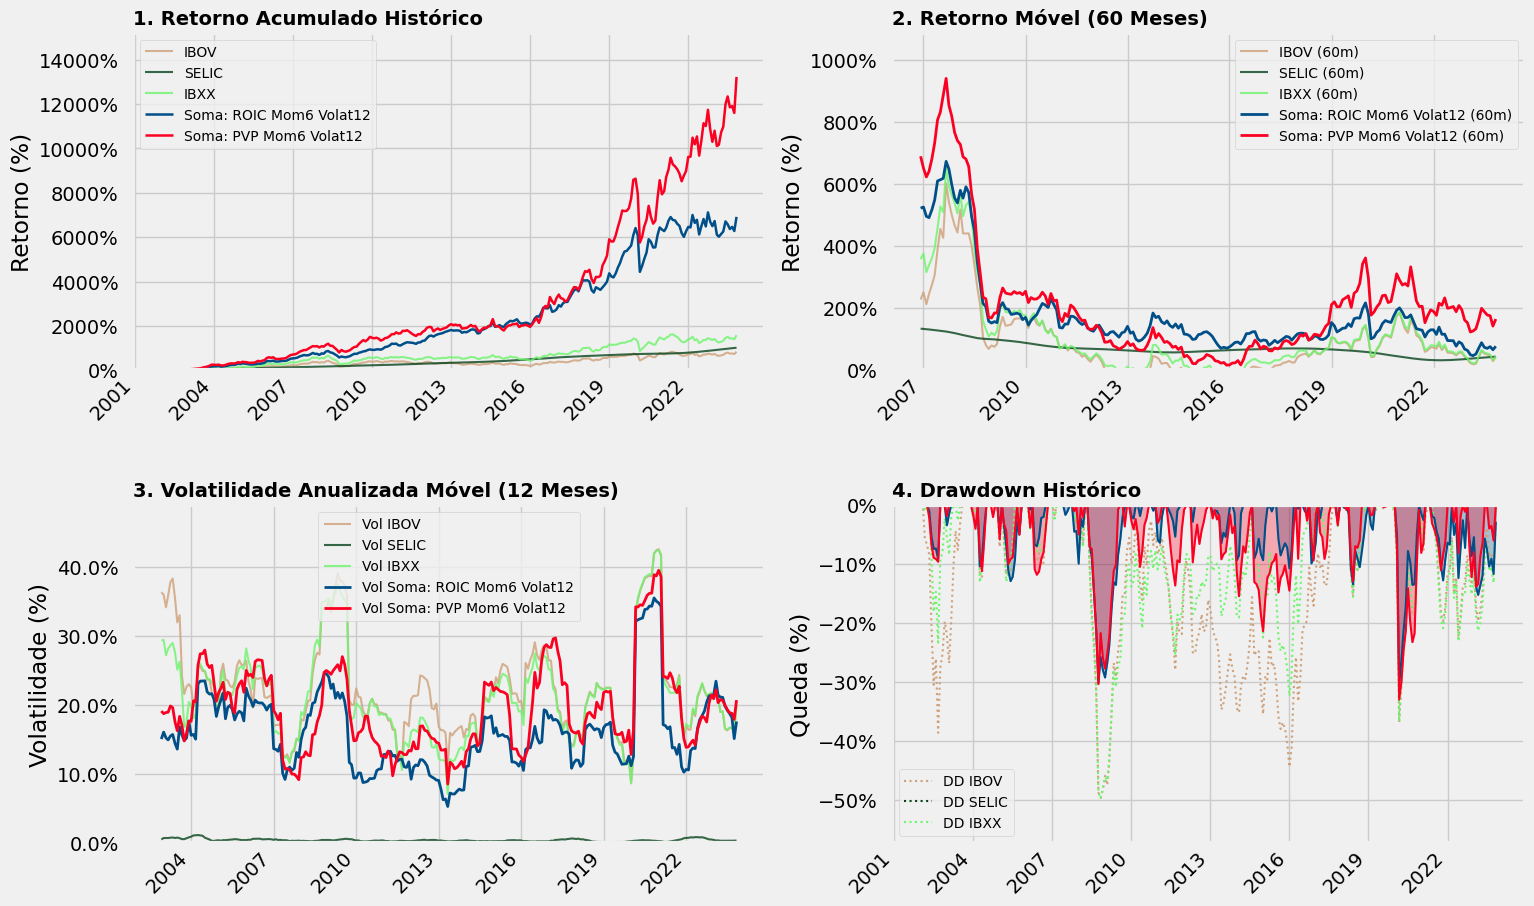

In [109]:
plotar_dashboard_comparativo([Modelo2_ret_vol1,modelo2_ret_vol2]);

## **Modelo 3 - Maior Alpha:**

Neste modelo, o objetivo é **maximizar o Alpha**, isto é, o retorno excedente da carteira em relação ao IBOV (referência utilizada no Grid Search) que não é explicado pela exposição ao mercado (Beta). Buscamos, portanto, as combinações de fatores capazes de gerar o maior “lucro limpo” descorrelacionado dos movimentos gerais da bolsa.

Com base nos fatores mais relevantes identificados nos modelos anteriores, realizamos o grid search utilizando a função **grid_search_fatores()** com o objetivo configurado para 'Alpha', testando combinações entre os seguintes indicadores: **ROIC, Mom6, PVP, Volat12, MTUM12, ROE e EV_EBIT**.

O EV_EBIT foi incluído neste modelo por ser uma métrica clássica de valuation relativa, que relaciona o valor da empresa (Enterprise Value) ao seu lucro operacional (EBIT). Diferentemente do PVP, o EV_EBIT oferece uma visão mais completa da atratividade da ação, sendo menos influenciado pela estrutura de capital das empresas. Sua inclusão teve como objetivo ampliar o escopo de fatores de valor na busca por Alpha incremental.

Importante observar que a **adição de mais fatores aumentou significativamente o número de combinações testadas** (saltando de 70 para 140 backtests), tornando o processamento mais custoso. Por isso, ao utilizar a função **grid_search_fatores()**, recomenda-se ter clareza sobre os fatores mais promissores antes de expandir o universo de teste, evitando sobrecarga computacional desnecessária.

In [110]:
melhor_comb_m3_alpha, resultados_m3_alpha = grid_search_fatores(
    fatores_disponiveis=['ROIC','Mom6','PVP','Volat12','MTUM12','ROE','EV_EBIT'],
    list_num_fatores=[3,4],
    objetivo='Alpha',     
    filtro_fim=20,      
    dados=dados,
    referencia=indices['IBOV'],
    list_ranking_styles=['Soma', 'Percentil']
);

Grid Search:
Total de backtests programados: 140
Testando [Soma] com 3 fatores (35 combinações)...
Testando [Soma] com 4 fatores (35 combinações)...
Testando [Percentil] com 3 fatores (35 combinações)...
Testando [Percentil] com 4 fatores (35 combinações)...
FIM DO GRID Search
Objetivo: Alpha
Melhor Método de Ranking: Soma
Melhor Combinação Encontrada: ['Mom6', 'PVP', 'Volat12']
Maior Alpha (Retorno Excedente) Atingido: 15.36%



In [111]:
resultados_m3_alpha.head(50)


,Método,Qtd Fatores,Combinação,Retorno Anualizado (%),Retorno Acumulado (%),Volatilidade (%),Alpha Anualizado (%),Beta,Drawdown (%),Retorno/Volatilidade,Score Alpha
0,Soma,3,"[Mom6, PVP, Volat12]",25.01,13224.92,20.47,15.36,0.71,-32.94,1.22,0.153552
1,Percentil,3,"[Mom6, PVP, Volat12]",24.73,12577.86,20.59,15.04,0.72,-33.22,1.20,0.150405
2,Soma,3,"[ROIC, PVP, MTUM12]",25.05,13312.69,20.97,15.00,0.75,-44.25,1.19,0.150036
3,Percentil,3,"[ROIC, PVP, MTUM12]",24.71,12548.59,20.51,14.87,0.73,-42.23,1.21,0.148684
4,Soma,4,"[Mom6, PVP, Volat12, MTUM12]",23.91,10882.84,20.16,14.83,0.67,-34.83,1.19,0.148332
5,Percentil,4,"[Mom6, PVP, Volat12, MTUM12]",23.85,10756.73,20.16,14.77,0.68,-34.97,1.18,0.147710
6,Soma,4,"[ROIC, Mom6, PVP, MTUM12]",24.28,11614.47,21.30,14.67,0.73,-41.25,1.14,0.146746
7,Percentil,4,"[ROIC, Mom6, PVP, MTUM12]",23.89,10838.99,21.09,14.42,0.72,-40.62,1.13,0.144209
8,Soma,3,"[Mom6, Volat12, MTUM12]",22.66,8697.10,19.15,14.22,0.63,-35.80,1.18,0.142216
9,Percentil,3,"[Mom6, Volat12, MTUM12]",22.65,8669.73,19.11,14.22,0.63,-35.74,1.19,0.142198


In [112]:
Modelo3_alpha2 = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'SELIC','IBXX']],'Soma',['ROIC', 'PVP', 'MTUM12'],verbose=True)
Modelo3_alpha1 = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'SELIC','IBXX']],'Soma',['Mom6', 'MTUM12', 'EV_EBIT']	,verbose=True)


ANÁLISE DE PERFORMANCE: Portfolio [ROIC, PVP, MTUM12]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),13312.69,25.05,20.97,1.19,-44.25,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,15.0,0.0,0.75,0.0
2,SELIC,1017.88,11.64,1.32,8.82,0.00,6.84,0.5599,1.62,0.099
3,IBXX,1581.81,13.74,22.46,0.61,-49.74,12.27,0.0,0.81,0.0



ANÁLISE DE PERFORMANCE: Portfolio [Mom6, MTUM12, EV_EBIT]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),7306.87,21.70,21.90,0.99,-44.37,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,12.24,0.0,0.76,0.0
2,SELIC,1017.88,11.64,1.32,8.82,0.00,12.54,0.3079,0.88,0.3935
3,IBXX,1581.81,13.74,22.46,0.61,-49.74,9.5,0.0003,0.82,0.0


### **Resultados do Modelo 3**

Os resultados do Modelo 3 confirmam a robustez das estratégias multifatoriais na geração de Alpha (retorno excedente). Embora a otimização tenha sido realizada com base no IBOV como benchmark principal, as carteiras também apresentaram excelente desempenho quando comparadas ao IBXX.

A **carteira [Mom6, PVP, Volat12]** destacou-se com o **maior Alpha vs IBOV (15,36% ao ano)**, retorno anualizado de 25,01%, volatilidade de 20,47% e Drawdown Máximo de -32,94%. **Contra o IBXX**, essa carteira gerou **Alpha de 12,88% ao ano (Beta 0,76)**.

A **carteira [ROIC, PVP, MTUM12]** também entregou Alpha muito forte contra o IBOV **(15,00% ao ano)** e o maior retorno acumulado (13.312,69%). **Contra o IBXX**, seu **Alpha foi de 12,27% ao ano (Beta 0,81)**.
Comparação com os índices de referência:

Ambas as carteiras superaram significativamente tanto o IBOV quanto o IBXX em termos de Alpha (todos com p-valor = 0.0).
[Mom6, PVP, Volat12]: Alpha 15,36% (IBOV) / 12,88% (IBXX) — Beta 0,71 (IBOV) / 0,76 (IBXX).
[ROIC, PVP, MTUM12]: Alpha 15,00% (IBOV) / 12,27% (IBXX) — Beta 0,75 (IBOV) / 0,81 (IBXX).

Deste modo, podemos concluir que a busca pelo maior Alpha valida novamente a importância dos “freios estatísticos”. A combinação de fatores como Volat12 (baixa volatilidade), PVP (valor) e momentum permitiu gerar retorno excedente consistente em relação tanto ao IBOV quanto ao IBXX, com boa proteção contra grandes quedas e menor dependência dos movimentos gerais do mercado.

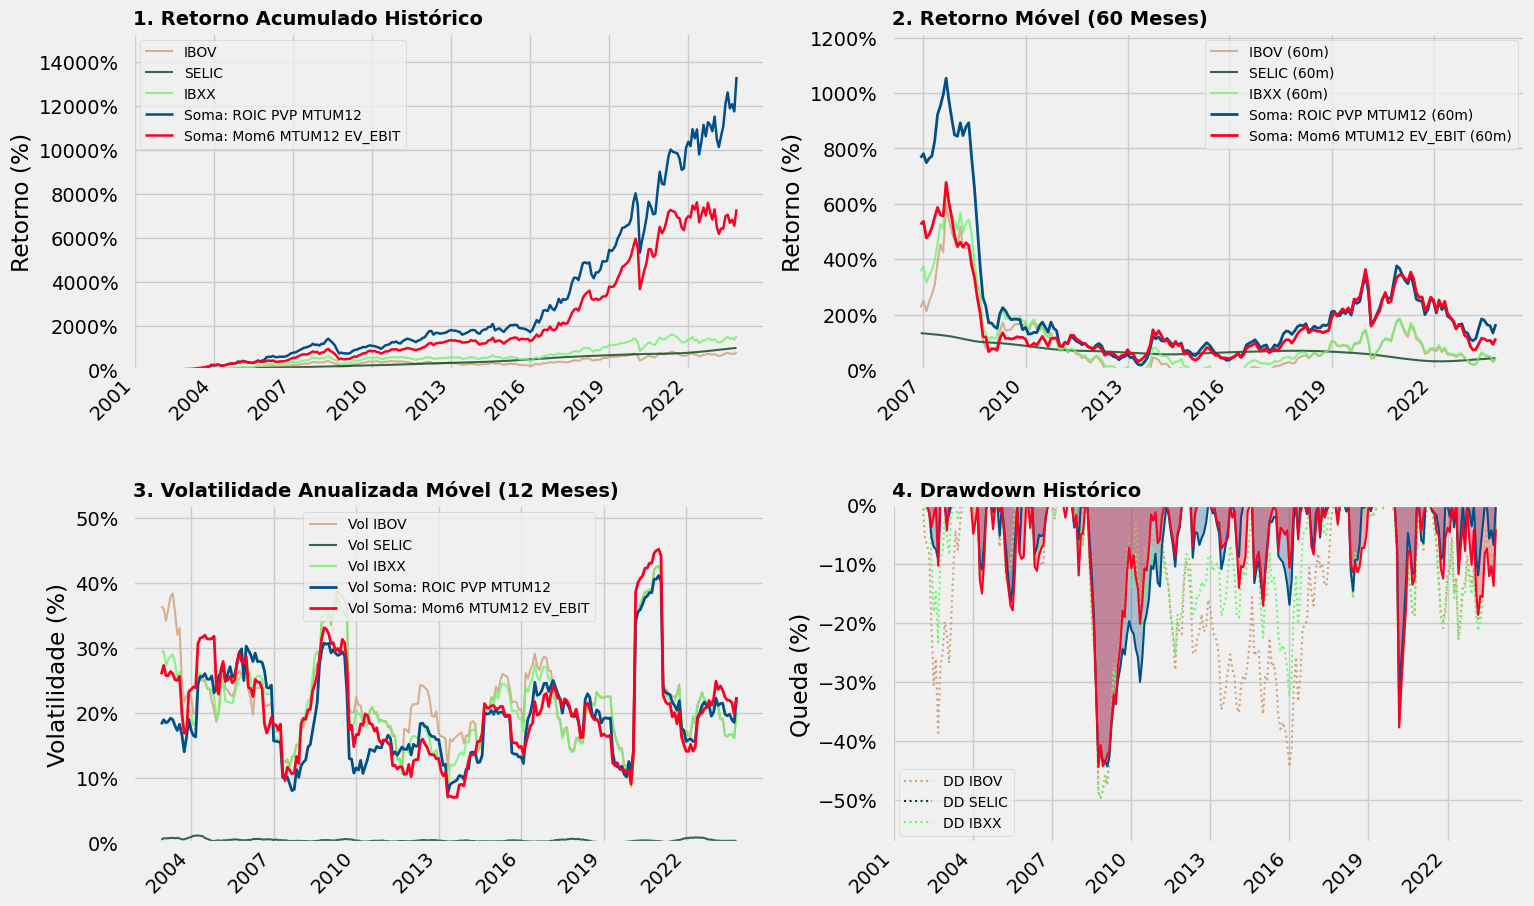

In [113]:
plotar_dashboard_comparativo([Modelo3_alpha2,Modelo3_alpha1])

## **Modelo 4 - Menor Volatilidade:**

Neste modelo, o objetivo central é a minimização da volatilidade, buscando construir um portfólio estritamente defensivo e resiliente. O foco é evitar que a carteira oscile bastante em momentos de crise do mercado.

Para a execução deste **Grid Search**, o espaço de busca contou com os fatores **ROIC, Volat12, MTUM12, EV_EBIT, EBIT_DIVLIQ, Volat6** e **PVP**. Essa combinação foi desenhada com foco absoluto na estabilidade, cruzando os indicadores de risco direto (**Volat12** e **Volat6**) com filtros de qualidade, saúde financeira e **valuation**, cujos conceitos teóricos foram apresentados na introdução deste relatório. A permanência do **MTUM12** atua aqui como uma salvaguarda importante, impedindo que o algoritmo selecione ativos que apresentem uma tendência de queda estrutural.

In [114]:
melhor_comb_m4_vol, resultados_m4_vol = grid_search_fatores(
    fatores_disponiveis=['ROIC','Volat12','MTUM12','EV_EBIT','EBIT_DIVLIQ','Volat6','PVP'],
    list_num_fatores=[3,4],
    objetivo='Volatilidade',     
    filtro_fim=20,      
    dados=dados,
    referencia=indices['IBOV'],
    list_ranking_styles=['Soma', 'Percentil']
)

Grid Search:
Total de backtests programados: 140
Testando [Soma] com 3 fatores (35 combinações)...
Testando [Soma] com 4 fatores (35 combinações)...
Testando [Percentil] com 3 fatores (35 combinações)...
Testando [Percentil] com 4 fatores (35 combinações)...
FIM DO GRID Search
Objetivo: Volatilidade
Melhor Método de Ranking: Soma
Melhor Combinação Encontrada: ['ROIC', 'Volat12', 'EBIT_DIVLIQ', 'Volat6']
Volatilidade Mínima Atingida: 16.26%



In [115]:
resultados_m4_vol.head(5)


,Método,Qtd Fatores,Combinação,Retorno Anualizado (%),Retorno Acumulado (%),Volatilidade (%),Alpha Anualizado (%),Beta,Drawdown (%),Retorno/Volatilidade,Score Volatilidade
0,Soma,4,"[ROIC, Volat12, EBIT_DIVLIQ, Volat6]",17.06,3059.92,16.26,9.58,0.58,-29.80,1.05,0.162587
1,Soma,4,"[Volat12, MTUM12, EBIT_DIVLIQ, Volat6]",18.86,4308.89,16.35,11.37,0.56,-31.14,1.15,0.163465
2,Percentil,4,"[ROIC, Volat12, EBIT_DIVLIQ, Volat6]",16.46,2721.19,16.35,9.03,0.58,-29.76,1.01,0.163535
3,Percentil,3,"[ROIC, Volat12, Volat6]",16.28,2625.44,16.36,8.97,0.58,-30.39,0.99,0.163595
4,Percentil,4,"[Volat12, MTUM12, EBIT_DIVLIQ, Volat6]",18.71,4190.10,16.38,11.20,0.57,-31.14,1.14,0.163755


In [116]:
Modelo4_vol1 = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'SELIC','IBXX']],'Soma',['ROIC', 'Volat12', 'EBIT_DIVLIQ', 'Volat6'],verbose=True)
Modelo4_vol2 = criar_portifolio_multiplos_fatores(20, dados, indices[['IBOV', 'SELIC','IBXX']],'Soma',['Volat12', 'MTUM12', 'EBIT_DIVLIQ', 'Volat6'],verbose=True)


ANÁLISE DE PERFORMANCE: Portfolio [ROIC, Volat12, EBIT_DIVLIQ, Volat6]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),3059.92,17.06,16.26,1.05,-29.80,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,9.58,0.0,0.58,0.0
2,SELIC,1017.88,11.64,1.32,8.82,0.00,4.81,0.5973,1.12,0.1419
3,IBXX,1581.81,13.74,22.46,0.61,-49.74,7.48,0.0,0.63,0.0



ANÁLISE DE PERFORMANCE: Portfolio [Volat12, MTUM12, EBIT_DIVLIQ, Volat6]


,Ativo,Ret. Acumulado (%),Ret. Anualizado (%),Volatilidade (%),Retorno/Volatilidade,Drawdown Máximo (%),Alpha vs Ref (%),P-val Alpha,Beta vs Ref,P-val Beta
0,Carteira (Soma),4308.89,18.86,16.35,1.15,-31.14,-,-,-,-
1,IBOV,837.84,10.75,23.66,0.45,-49.59,11.37,0.0,0.56,0.0
2,SELIC,1017.88,11.64,1.32,8.82,0.00,6.33,0.4895,1.12,0.143
3,IBXX,1581.81,13.74,22.46,0.61,-49.74,9.24,0.0,0.61,0.0


### **Resultados do Modelo 4**
Os resultados do Modelo 4 foram muito positivos. Conseguimos reduzir significativamente a volatilidade das carteiras sem abrir mão de retornos razoáveis e com excelente controle de risco.
A carteira que apresentou a menor volatilidade foi [ROIC, Volat12, EBIT_DIVLIQ, Volat6], com volatilidade anualizada de apenas 16,26% (bem abaixo dos 23,66% do IBOV), Drawdown Máximo de -29,80% e Alpha de 9,58% ao ano contra o IBOV (Beta 0,58). Apesar do retorno mais moderado (17,06% anualizado), ela se mostrou a mais estável entre todas testadas.
A segunda carteira relevante, [Volat12, MTUM12, EBIT_DIVLIQ, Volat6], ofereceu um bom equilíbrio entre baixa volatilidade (16,35%) e maior retorno (18,86% anualizado), gerando Alpha de 11,37% ao ano contra o IBOV (Beta 0,56) e Drawdown Máximo de -31,14%.
Comparação com os índices de referência:

Ambas as carteiras apresentaram volatilidade substancialmente inferior ao IBOV (23,66%) e ao IBXX (22,46%).
Contra o IBXX, a primeira carteira gerou Alpha de 7,48% e a segunda de 9,24% ao ano.
O Beta abaixo de 0,60 em ambas demonstra forte descorrelação em relação ao mercado, confirmando o sucesso na construção de uma carteira defensiva.

Deste modo, podemos concluir que é possível construir carteiras com baixa volatilidade sem sacrificar completamente o retorno. A combinação de fatores de baixa volatilidade (Volat12 e Volat6) com indicadores de qualidade operacional (ROIC) e saúde financeira (EBIT_DIVLIQ) mostrou-se extremamente eficaz, gerando portfólios mais resilientes e com menor exposição aos solavancos do mercado brasileiro.

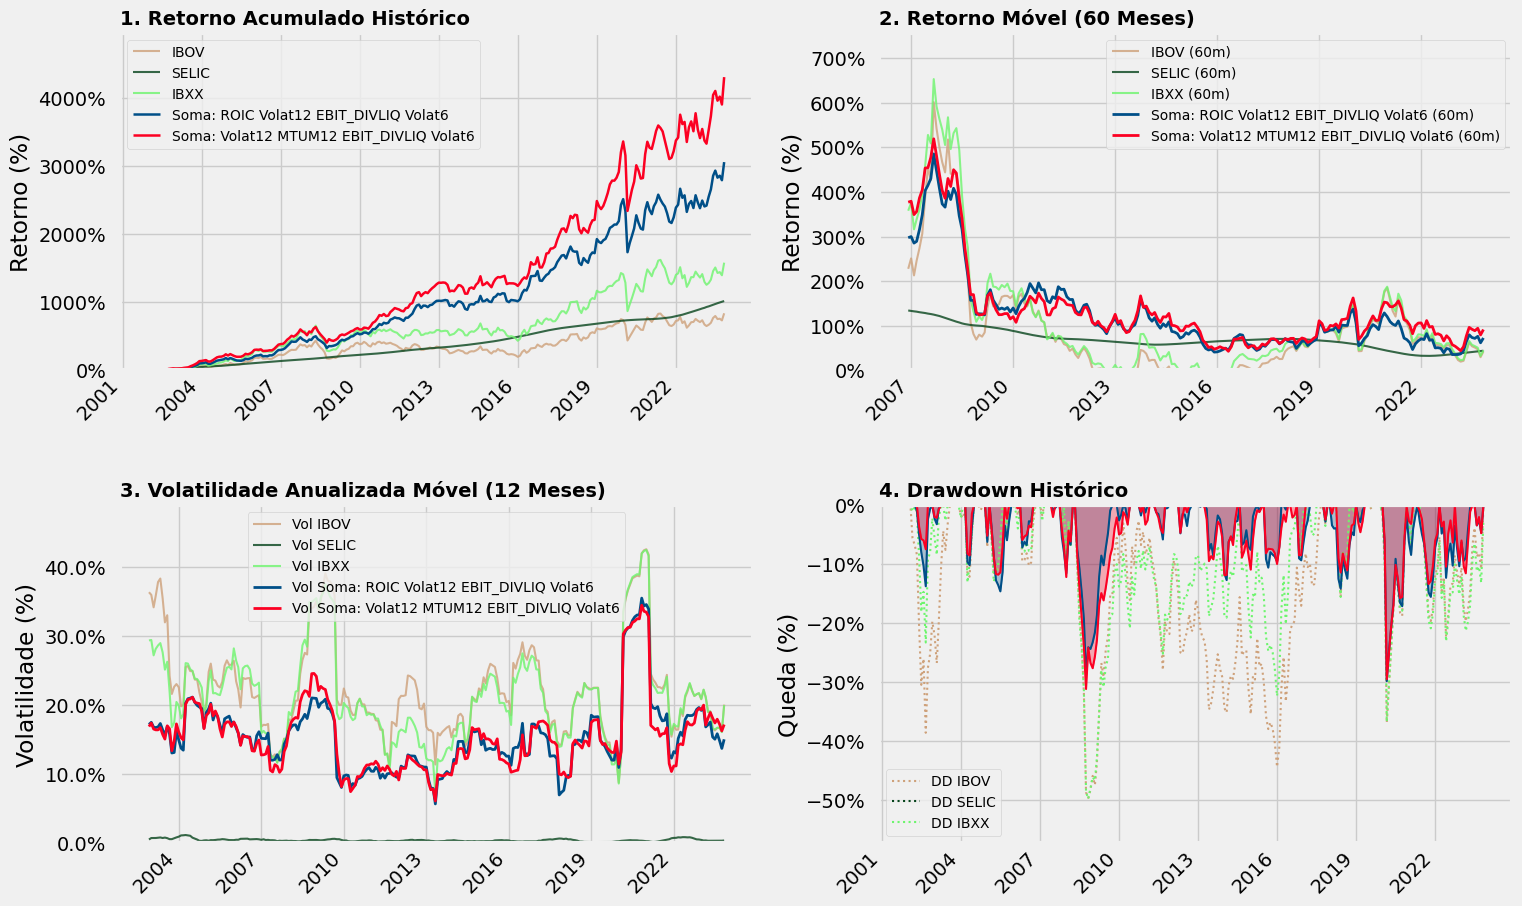

In [117]:
plotar_dashboard_comparativo([Modelo4_vol1,Modelo4_vol2])

## **Conclusão**

Este trabalho demonstrou a importância e a eficiência da abordagem multifatorial na seleção de portfólios de ações. A utilização do *Grid Search* permitiu explorar de forma sistemática diversas combinações de fatores, revelando que a **diversificação entre diferentes classes de indicadores** (valor, momentum, qualidade e risco) é fundamental para obter bom desempenho no longo prazo.

Ficou claro que estratégias puramente agressivas, baseadas apenas em fatores de retorno, geram altos *drawdowns* em períodos de crise, comprometendo o resultado final. Por outro lado, a inclusão de filtros de qualidade (ROIC), saúde financeira e especialmente de controle de volatilidade produziu carteiras mais estáveis e resilientes, permitindo que o efeito dos juros compostos atuasse de forma mais eficiente.

O destaque do estudo foi a combinação **PVP + Mom6 + Volat12**, que se mostrou a mais equilibrada de todo o trabalho. Esta carteira apresentou excelente desempenho simultâneo em retorno acumulado, relação retorno/volatilidade e alpha (15,36% ao ano contra o IBOV), além de drawdown controlado mesmo nos momentos mais difíceis do mercado brasileiro.

Surpreendentemente, a carteira mais agressiva não foi a que entregou o maior retorno acumulado no período analisado. Essa constatação reforça uma lição importante: proteger o capital durante as crises é tão ou mais relevante do que buscar o maior ganho possível. O uso do Grid Search foi essencial para validar essas conclusões de forma objetiva, reduzindo viés de seleção manual.

Em uma aplicação prática, priorizaria a estratégia [PVP, Mom6, Volat12] pela sua consistência e robustez ao longo dos diferentes critérios avaliados.